# 08 — Synthetic multiplicity datasets

**Purpose:** Train Rashomon models on three synthetic designs with known high-multiplicity regions, compute predictive variance, Moran's I, and LISA; visualize variance and HH hotspots; report recovery (Precision/Recall/Jaccard) against ground truth; fit decision trees (HH vs non-HH); run null experiments.

- **Part A:** single ambiguous island (boundary/aleatoric XOR mechanism)
- **Part B:** three islands + outliers
- **Part C:** structural exception islands away from the ordinary decision boundary (COMPAS-like mechanism)


## 1. Imports and path setup

In [32]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import RAW_RESULTS, thesis_output_dirs, apply_thesis_plot_style

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
apply_thesis_plot_style()
from scipy import stats
from sklearn.tree import DecisionTreeClassifier, plot_tree

from data import make_preprocessor
from src.synthetic_data import (
    make_synthetic_multiplicity_dataset,
    make_synth_three_islands_plus_outliers,
    make_synth_nonboundary_islands,
)
from src.training_pipeline import run_one_training_run, save_run_artifacts
from analysis.cache import load_or_compute_df
from analysis.run_analysis import (
    load_meta,
    load_P_test,
    select_rashomon_global,
    run_spatial,
    run_null,
    pointwise_variance,
    compute_multiplicity_metrics,
)
from analysis.synthetic_validation import (
    compute_single_island_fdr_sensitivity,
    compute_three_islands_fdr_sensitivity,
    compute_structural_exceptions_fdr_sensitivity,
)

RESULTS_DIR = RAW_RESULTS
TABLE_DIR, FIG_DIR = thesis_output_dirs("synthetic")
K = 25
K_NN = 30
SEED = 42
FORCE_RECOMPUTE = False
CACHE_VERSION = "v1"
CACHE_DIR = ROOT / "thesis_outputs" / "cache" / "notebooks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


## 2. Generate synthetic data

Stable region: two well-separated blobs. Ambiguous island: uniform disk around origin with weak XOR-like P(y=1|x).

Samples: 3000, island (ambiguous): 600, stable: 2400
Features: {'numeric': ['x1', 'x2'], 'categorical': []}


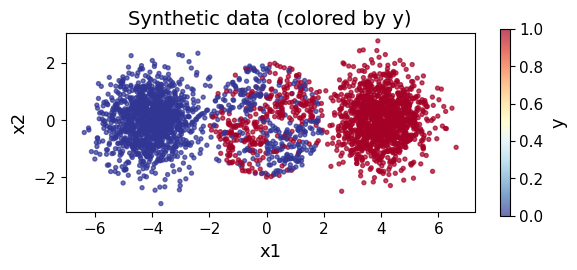

In [33]:
X, y, feature_info, gt = make_synthetic_multiplicity_dataset(
    n_samples=3000,
    p_island=0.2,
    island_delta=0.30,
    random_state=SEED,
)
print(f"Samples: {len(X)}, island (ambiguous): {gt.island_mask.sum()}, stable: {gt.stable_mask.sum()}")
print("Features:", feature_info)

# Plot data colored by target y
plt.figure(figsize=(6, 5))
plt.scatter(X["x1"], X["x2"], c=y, s=8, alpha=0.7, cmap="RdYlBu_r")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Synthetic data (colored by y)")
plt.colorbar(label="y", shrink=0.4)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / f"single_island_ground_truth.pdf", bbox_inches="tight")
plt.show()

## 3. Train models and save artifacts

Single split (60/20/20), multiple families (LogReg, RF, GBM, MLP, kNN), top-K by validation Brier. Save to `results/synthetic/seed={SEED}/` so analysis functions can load from run_dir.

In [34]:
preprocessor_factory = lambda fi: make_preprocessor(fi, scale_numeric=True)

split, meta, P_val, P_test, _ = run_one_training_run(
    X=X,
    y=y,
    feature_info=feature_info,
    preprocessor_factory=preprocessor_factory,
    outer_seed=SEED,
    n_candidates_per_family=50,
    test_size=0.2,
    val_size=0.2,
    verbose=1,
)

run_dir = RESULTS_DIR / "synthetic" / f"seed={SEED}"
run_dir.mkdir(parents=True, exist_ok=True)
save_run_artifacts(run_dir, split, meta, P_val, P_test, config={"dataset": "synthetic", "seed": SEED})

# Preprocessed X_test for spatial analysis (same as used inside pipelines)
preprocessor = preprocessor_factory(feature_info)
X_train = X.iloc[split["train"]]
y_train = y.iloc[split["train"]]
preprocessor.fit(X_train, y_train)
X_test_raw = X.iloc[split["test"]]
X_test = preprocessor.transform(X_test_raw)
if hasattr(X_test, "toarray"):
    X_test = np.asarray(X_test)
else:
    X_test = np.asarray(X_test)

print(f"Saved to {run_dir}")
print(f"Candidates: {len(meta)}, test size: {X_test.shape[0]}")

  [LogReg] 50 candidates trained
  [kNN] 50 candidates trained
  [RF] 50 candidates trained
  [GBM] 50 candidates trained
  [MLP] 50 candidates trained
Saved to C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\synthetic\seed=42
Candidates: 250, test size: 600


## 4. Rashomon selection and metrics

Select top-K by validation Brier; compute predictive variance, Moran's I, LISA (HH/LL masks).

In [35]:
n_cand = len(load_meta(run_dir))
K_actual = min(K, n_cand)
spatial = run_spatial(run_dir, X_test, K=K_actual, k=K_NN)
mult = compute_multiplicity_metrics(load_P_test(run_dir)[select_rashomon_global(run_dir, K=K_actual)], epsilon=0.05)

v = pointwise_variance(load_P_test(run_dir)[select_rashomon_global(run_dir, K=K_actual)], ddof=0)
HH_mask = spatial["HH_mask"]
LL_mask = spatial["LL_mask"]

print(f"Moran's I: {spatial['moran_i']:.4f}")
print(f"Mean variance: {mult['mean_variance']:.6f}")
print(f"HH count: {HH_mask.sum()}, LL count: {LL_mask.sum()}")

Moran's I: 0.2463
Mean variance: 0.001638
HH count: 105, LL count: 345


## 4a. Recovery metrics (HH vs ground-truth island)

Main result uses **BH-FDR with α = 0.05** to determine HH points. Compare LISA HH hotspots to the ground-truth ambiguous region (island). Report **Precision**, **Recall**, and **Jaccard** as quantitative recovery metrics.

In [36]:
test_idx = split["test"]
island_test = gt.island_mask[test_idx]  # ground-truth ambiguous region on test set

# HH_mask: predicted hotspots (LISA); island_test: true ambiguous region
tp = (HH_mask & island_test).sum()
pred_pos = HH_mask.sum()
true_pos = island_test.sum()

# Edge cases: no HH or no island
if pred_pos == 0:
    precision = np.nan
else:
    precision = tp / pred_pos
if true_pos == 0:
    recall = np.nan
else:
    recall = tp / true_pos

union = (HH_mask | island_test).sum()
if union == 0:
    jaccard = np.nan
else:
    jaccard = tp / union

print("Recovery of ground-truth island by LISA HH:")
print(f"  Precision (HH ∩ island / HH): {precision:.4f}")
print(f"  Recall    (HH ∩ island / island): {recall:.4f}")
print(f"  Jaccard   (HH ∩ island / HH ∪ island): {jaccard:.4f}")
print(f"  TP={int(tp)}, |HH|={int(pred_pos)}, |island|={int(true_pos)}")

Recovery of ground-truth island by LISA HH:
  Precision (HH ∩ island / HH): 0.9429
  Recall    (HH ∩ island / island): 0.8250
  Jaccard   (HH ∩ island / HH ∪ island): 0.7857
  TP=99, |HH|=105, |island|=120


### 4b. FDR α sensitivity (single island)

Sensitivity over **α ∈ {0.01, 0.05, 0.10, 0.20}**: #HH, #components (min size 5), max component size, Jaccard(HH, ground-truth island); **Precision** and **Recall** (HH vs GT); **DT Precision** and **DT Recall** (decision tree predicting HH vs non-HH, evaluated against GT island).

FDR α sensitivity (single island):


,α,#HH,#components,max_component_size,Jaccard,Precision,Recall,DT Precision,DT Recall
0,0.01,90,1,90,0.721311,0.977778,0.733333,0.974026,0.625000
1,0.05,105,1,105,0.785714,0.942857,0.825000,0.963636,0.883333
2,0.10,107,1,107,0.787402,0.934579,0.833333,0.946429,0.883333
3,0.20,110,1,110,0.782946,0.918182,0.841667,0.929825,0.883333


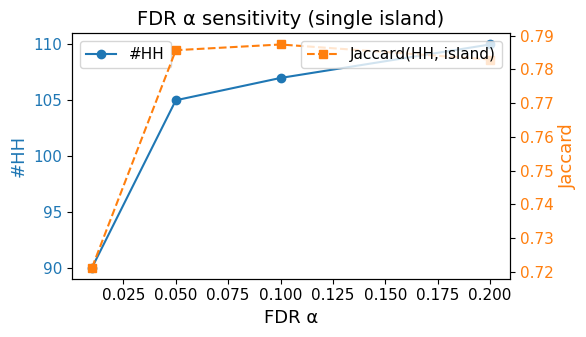

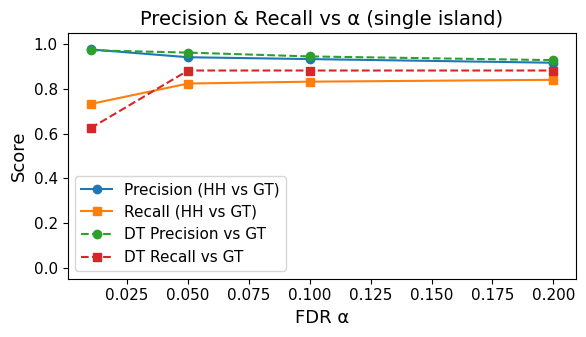

In [37]:
# FDR α sensitivity (Part A): same v, varying α

X_test_2d_a = np.column_stack([X_test_raw["x1"].values, X_test_raw["x2"].values])
fdr_alphas = [0.01, 0.05, 0.10, 0.20]

sens_df = load_or_compute_df(
    CACHE_DIR / f"nb08_single_island_fdr_{CACHE_VERSION}.parquet",
    lambda: compute_single_island_fdr_sensitivity(
        v,
        X_test,
        X_test_2d_a,
        island_test,
        fdr_alphas,
        k_nn=K_NN,
        seed=SEED,
    ),
    force=FORCE_RECOMPUTE,
)
print("FDR α sensitivity (single island):")
display(sens_df)

# Small figure: #HH and Jaccard vs α
fig, ax1 = plt.subplots(figsize=(6, 3.5))
ax1.set_xlabel("FDR α")
ax1.plot(sens_df["α"], sens_df["#HH"], "o-", color="C0", label="#HH")
ax1.set_ylabel("#HH", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax2 = ax1.twinx()
ax2.plot(sens_df["α"], sens_df["Jaccard"], "s--", color="C1", label="Jaccard(HH, island)")
ax2.set_ylabel("Jaccard", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
plt.title("FDR α sensitivity (single island)")
plt.tight_layout()
plt.savefig(FIG_DIR / f"single_island_fdr_sensitivity.pdf", bbox_inches="tight")
plt.show()
# Precision & Recall vs α (HH vs GT and DT vs GT)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.set_xlabel("FDR α")
ax.plot(sens_df["α"], sens_df["Precision"], "o-", label="Precision (HH vs GT)")
ax.plot(sens_df["α"], sens_df["Recall"], "s-", label="Recall (HH vs GT)")
ax.plot(sens_df["α"], sens_df["DT Precision"], "o--", label="DT Precision vs GT")
ax.plot(sens_df["α"], sens_df["DT Recall"], "s--", label="DT Recall vs GT")
ax.set_ylabel("Score")
ax.legend(loc="best", fontsize=11)
ax.set_ylim(-0.05, 1.05)
plt.title("Precision & Recall vs α (single island)")
plt.tight_layout()
plt.savefig(FIG_DIR / f"single_island_fdr_sensitivity_prec_recall.pdf", bbox_inches="tight")
plt.show()


## 5. Visualize predictive variance and HH points

Test set in (x1, x2): color by pointwise variance; highlight HH hotspots. Optionally cluster and show variance / HH by cluster.

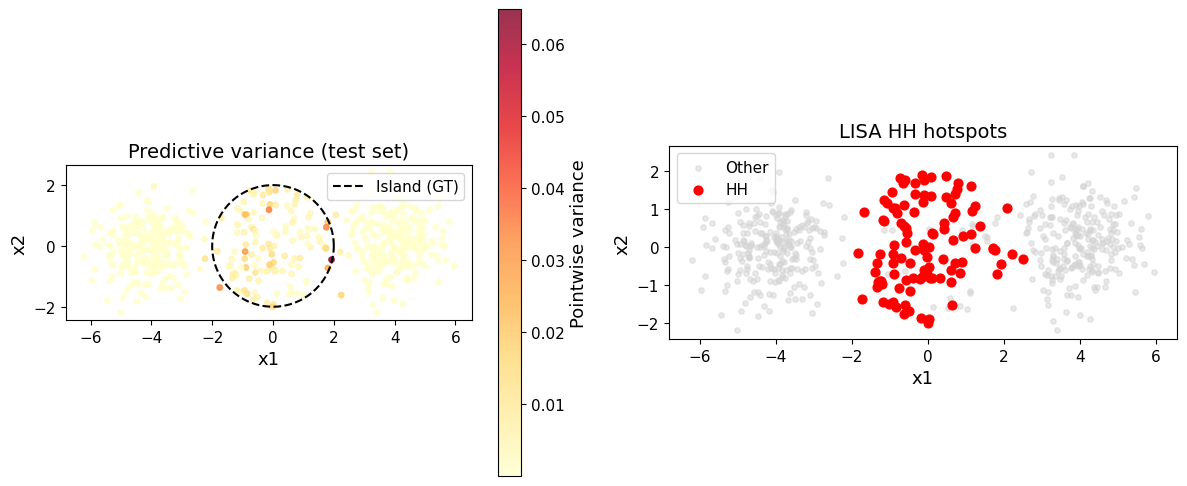

In [38]:
# Test set coordinates (original space for interpretability)
x1_test = X_test_raw["x1"].values
x2_test = X_test_raw["x2"].values
island_test = gt.island_mask[split["test"]]  # ground-truth ambiguous region on test set

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: scatter colored by pointwise variance; overlay ground-truth island circle
sc = axes[0].scatter(x1_test, x2_test, c=v, s=15, cmap="YlOrRd", alpha=0.8)
theta = np.linspace(0, 2 * np.pi, 200)
axes[0].plot(gt.island_radius * np.cos(theta), gt.island_radius * np.sin(theta), "k--", lw=1.5, label="Island (GT)")
plt.colorbar(sc, ax=axes[0], label="Pointwise variance")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title("Predictive variance (test set)")
axes[0].legend(loc="upper right", fontsize=11)
axes[0].set_aspect("equal")

# Right: HH points highlighted
axes[1].scatter(x1_test, x2_test, c="lightgray", s=15, alpha=0.5, label="Other")
axes[1].scatter(x1_test[HH_mask], x2_test[HH_mask], c="red", s=40, label="HH", zorder=5)
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("LISA HH hotspots")
axes[1].legend()
axes[1].set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / f"single_island_pred_var_lisa.pdf", bbox_inches="tight")
plt.show()

## 6. Decision tree: HH vs non-HH

Fit a decision tree on (x1, x2) to predict HH vs non-HH. Interpretable boundaries show which region the tree associates with LISA hotspots.


Decision tree (HH vs non-HH) accuracy on test set: 0.9650
Feature importances (x1, x2): [0.98292237 0.01707763]


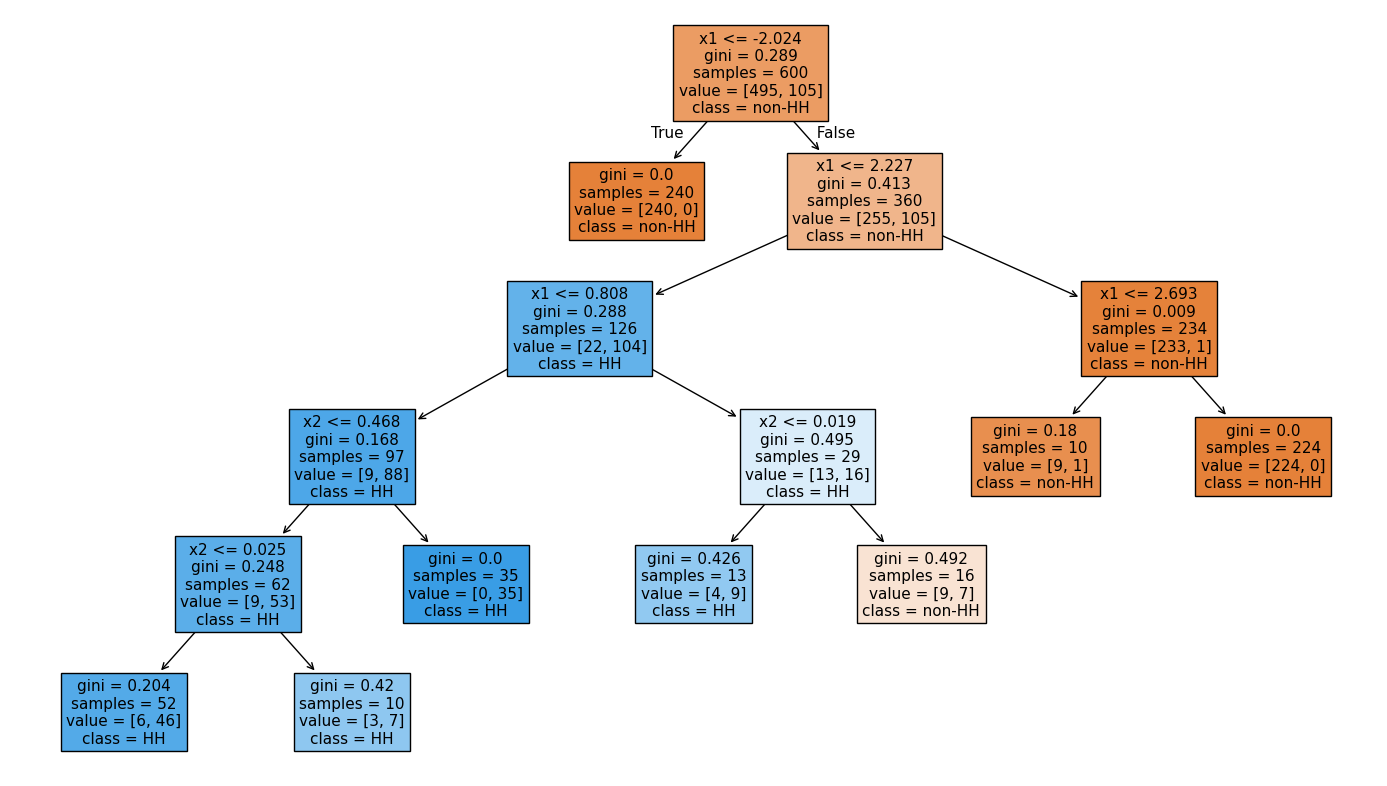

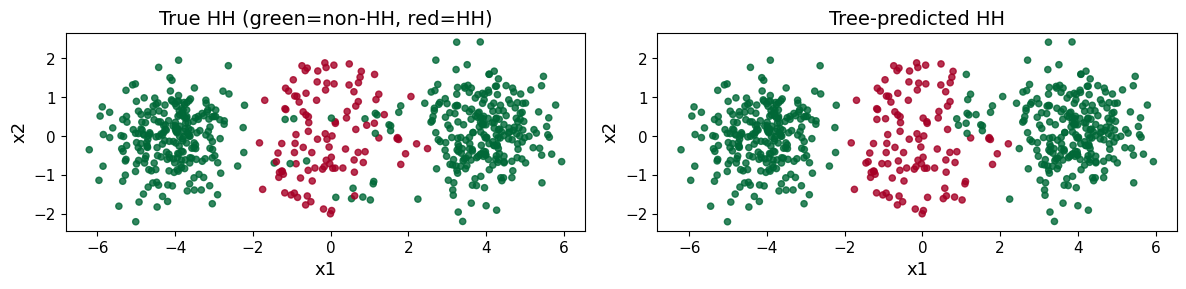

In [39]:
X_test_2d = np.column_stack([x1_test, x2_test])
y_hh = HH_mask.astype(int)  # 1 = HH, 0 = non-HH

dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=SEED)
dt.fit(X_test_2d, y_hh)
acc = dt.score(X_test_2d, y_hh)
print(f"Decision tree (HH vs non-HH) accuracy on test set: {acc:.4f}")
print("Feature importances (x1, x2):", dt.feature_importances_)

# Plot tree
fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(dt, feature_names=["x1", "x2"], class_names=["non-HH", "HH"], filled=True, ax=ax, fontsize=11)
plt.tight_layout()
plt.show()

# Scatter: true HH vs tree-predicted HH
pred_hh = dt.predict(X_test_2d)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(x1_test, x2_test, c=y_hh, s=20, cmap="RdYlGn_r", alpha=0.8)
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title("True HH (green=non-HH, red=HH)")
axes[0].set_aspect("equal")
axes[1].scatter(x1_test, x2_test, c=pred_hh, s=20, cmap="RdYlGn_r", alpha=0.8)
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("Tree-predicted HH")
axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()


## 7. Null experiment

Compare observed Moran's I to the null distribution (permuted predictions); plot histogram and empirical p-value.

Observed Moran's I: 0.2463
Null mean ± std: -0.0022 ± 0.0101
Empirical p-value (one-sided): 0.0099


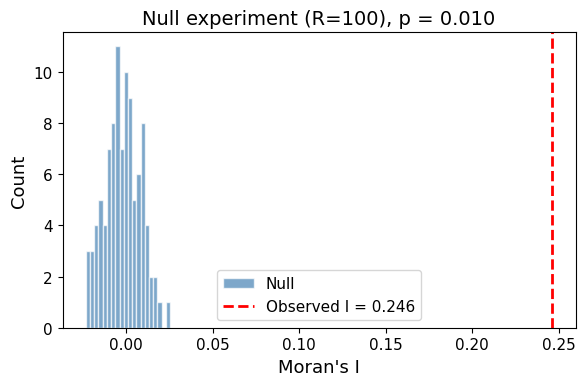

In [40]:
R_null = 100
null_res = run_null(run_dir, X_test, K=K_actual, R=R_null, k=K_NN, seed=SEED)
observed_I = spatial["moran_i"]
null_moran = null_res["null_moran_i"]
p_emp = (1 + np.sum(null_moran >= observed_I)) / (R_null + 1)

print(f"Observed Moran's I: {observed_I:.4f}")
print(f"Null mean ± std: {null_res['null_mean']:.4f} ± {null_res['null_std']:.4f}")
print(f"Empirical p-value (one-sided): {p_emp:.4f}")

plt.figure(figsize=(6, 4))
plt.hist(null_moran, bins=20, color="steelblue", alpha=0.7, edgecolor="white", label="Null")
plt.axvline(observed_I, color="red", linestyle="--", linewidth=2, label=f"Observed I = {observed_I:.3f}")
plt.xlabel("Moran's I")
plt.ylabel("Count")
plt.title(f"Null experiment (R={R_null}), p = {p_emp:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

### Thesis table: single-island synthetic validation summary

Compact recovery and spatial metrics for the main thesis synthetic-validation subsection.


In [41]:
single_island_tbl = pd.DataFrame([{
    "Design": "Single island",
    "|HH|": int(HH_mask.sum()),
    "Precision": precision,
    "Recall": recall,
    "Jaccard": jaccard,
    "Moran's I": float(spatial["moran_i"]),
    "Empirical p-value": float(p_emp),
}])
display(single_island_tbl)


,Design,|HH|,Precision,Recall,Jaccard,Moran's I,Empirical p-value
0,Single island,105,0.942857,0.825,0.785714,0.246333,0.009901


---
## Part B: Three islands + outliers

Same pipeline on a second synthetic dataset: two stable blobs, **three** ambiguous islands, and isolated **outliers** (high-variance points that should not form HH clusters). Ground truth: `island_mask` (any of the 3 islands), `outlier_mask`, `stable_mask`.

Samples: 5000, island: 1500, stable: 3400, outliers: 100


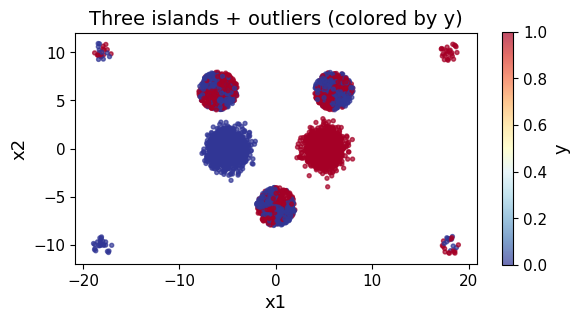

In [42]:
# Dataset 2: three islands + outliers
# (increased n_samples for more per-island mass, higher delta for stronger
#  model disagreement, islands spread further apart to avoid interference)
X, y, feature_info, gt = make_synth_three_islands_plus_outliers(
    n_samples=5000,
    p_islands=0.30,
    p_outliers=0.02,
    island_delta=0.30,
    random_state=SEED,
)
print(f"Samples: {len(X)}, island: {gt.island_mask.sum()}, stable: {gt.stable_mask.sum()}, outliers: {gt.outlier_mask.sum()}")

plt.figure(figsize=(6, 5))
plt.scatter(X["x1"], X["x2"], c=y, s=8, alpha=0.7, cmap="RdYlBu_r")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Three islands + outliers (colored by y)")
plt.colorbar(label="y", shrink=0.5)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / f"three_islands_ground_truth.pdf", bbox_inches="tight")
plt.show()

In [43]:
# Train and save to a separate run dir
run_dir = RESULTS_DIR / "synthetic_three_islands" / f"seed={SEED}"
run_dir.mkdir(parents=True, exist_ok=True)

preprocessor_factory = lambda fi: make_preprocessor(fi, scale_numeric=True)
split, meta, P_val, P_test, _ = run_one_training_run(
    X=X, y=y, feature_info=feature_info, preprocessor_factory=preprocessor_factory,
    outer_seed=SEED, n_candidates_per_family=50, test_size=0.2, val_size=0.2, verbose=1,
)
save_run_artifacts(run_dir, split, meta, P_val, P_test, config={"dataset": "synthetic_three_islands", "seed": SEED})

preprocessor = preprocessor_factory(feature_info)
preprocessor.fit(X.iloc[split["train"]], y.iloc[split["train"]])
X_test_raw = X.iloc[split["test"]]
X_test = np.asarray(preprocessor.transform(X_test_raw))
print(f"Saved to {run_dir}, test size: {X_test.shape[0]}")

  [LogReg] 50 candidates trained
  [kNN] 50 candidates trained
  [RF] 50 candidates trained
  [GBM] 50 candidates trained
  [MLP] 50 candidates trained
Saved to C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\synthetic_three_islands\seed=42, test size: 1000


In [44]:
# Rashomon + spatial
n_cand = len(load_meta(run_dir))
K_actual = min(K, n_cand)
spatial = run_spatial(run_dir, X_test, K=K_actual, k=K_NN)
mult = compute_multiplicity_metrics(load_P_test(run_dir)[select_rashomon_global(run_dir, K=K_actual)], epsilon=0.05)
v = pointwise_variance(load_P_test(run_dir)[select_rashomon_global(run_dir, K=K_actual)], ddof=0)
HH_mask = spatial["HH_mask"]
LL_mask = spatial["LL_mask"]
print(f"Moran's I: {spatial['moran_i']:.4f}, mean variance: {mult['mean_variance']:.6f}, HH: {HH_mask.sum()}, LL: {LL_mask.sum()}")

c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\weights.py:1294: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  out_w = W(neighbors, weights, id_order=self.id_order)
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\weights.py:1294: UserWarning: The we

Moran's I: 0.4215, mean variance: 0.001076, HH: 268, LL: 670


In [45]:
# Recovery: HH vs ground-truth island (any of the 3 islands)
test_idx = split["test"]
island_test = gt.island_mask[test_idx]
tp = (HH_mask & island_test).sum()
pred_pos = HH_mask.sum()
true_pos = island_test.sum()
precision = tp / pred_pos if pred_pos else np.nan
recall = tp / true_pos if true_pos else np.nan
union = (HH_mask | island_test).sum()
jaccard = tp / union if union else np.nan
print("Recovery of ground-truth islands by LISA HH:")
print(f"  Precision: {precision:.4f}, Recall: {recall:.4f}, Jaccard: {jaccard:.4f}")
print(f"  TP={int(tp)}, |HH|={int(pred_pos)}, |island|={int(true_pos)}")

Recovery of ground-truth islands by LISA HH:
  Precision: 0.9627, Recall: 0.8776, Jaccard: 0.8487
  TP=258, |HH|=268, |island|=294


### FDR α sensitivity (three islands)

Same sensitivity: α ∈ {0.01, 0.05, 0.10, 0.20} → #HH, #components, max component size, Jaccard(HH, GT island); Precision & Recall (HH vs GT); DT Precision & DT Recall (tree vs GT).

FDR α sensitivity (three islands):


,α,#HH,#components,max_component_size,Jaccard,Precision,Recall,DT Precision,DT Recall
0,0.01,267,3,101,0.845395,0.962547,0.874150,0.978571,0.931973
1,0.05,268,3,101,0.848684,0.962687,0.877551,0.978571,0.931973
2,0.10,268,3,101,0.848684,0.962687,0.877551,0.978571,0.931973
3,0.20,269,3,101,0.845902,0.959108,0.877551,0.978571,0.931973


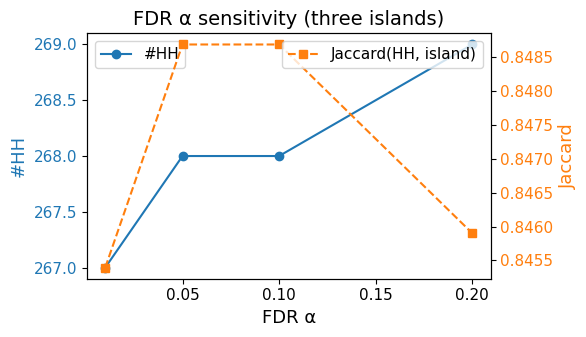

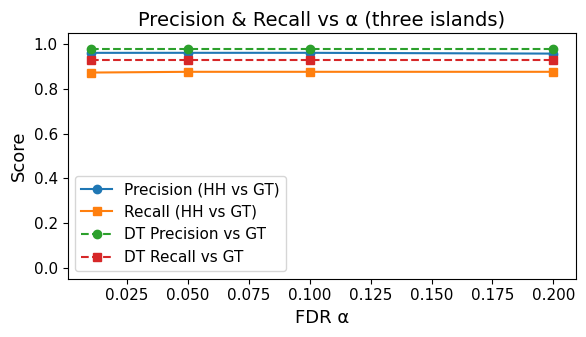

In [46]:
# FDR α sensitivity (Part B)
X_test_2d_b = np.column_stack([X_test_raw["x1"].values, X_test_raw["x2"].values])
fdr_alphas = [0.01, 0.05, 0.10, 0.20]

sens_df_b = load_or_compute_df(
    CACHE_DIR / f"nb08_three_islands_fdr_{CACHE_VERSION}.parquet",
    lambda: compute_three_islands_fdr_sensitivity(
        v,
        X_test,
        X_test_2d_b,
        island_test,
        fdr_alphas,
        k_nn=K_NN,
        seed=SEED,
    ),
    force=FORCE_RECOMPUTE,
)
print("FDR α sensitivity (three islands):")
display(sens_df_b)

fig, ax1 = plt.subplots(figsize=(6, 3.5))
ax1.set_xlabel("FDR α")
ax1.plot(sens_df_b["α"], sens_df_b["#HH"], "o-", color="C0", label="#HH")
ax1.set_ylabel("#HH", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax2 = ax1.twinx()
ax2.plot(sens_df_b["α"], sens_df_b["Jaccard"], "s--", color="C1", label="Jaccard(HH, island)")
ax2.set_ylabel("Jaccard", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
plt.title("FDR α sensitivity (three islands)")
plt.tight_layout()
plt.savefig(FIG_DIR / f"three_islands_fdr_sensitivity.pdf", bbox_inches="tight")
plt.show()
# Precision & Recall vs α (three islands)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.set_xlabel("FDR α")
ax.plot(sens_df_b["α"], sens_df_b["Precision"], "o-", label="Precision (HH vs GT)")
ax.plot(sens_df_b["α"], sens_df_b["Recall"], "s-", label="Recall (HH vs GT)")
ax.plot(sens_df_b["α"], sens_df_b["DT Precision"], "o--", label="DT Precision vs GT")
ax.plot(sens_df_b["α"], sens_df_b["DT Recall"], "s--", label="DT Recall vs GT")
ax.set_ylabel("Score")
ax.legend(loc="best", fontsize=11)
ax.set_ylim(-0.05, 1.05)
plt.title("Precision & Recall vs α (three islands)")
plt.tight_layout()
plt.savefig(FIG_DIR / f"three_islands_fdr_sensitivity_precision_recall.pdf", bbox_inches="tight")
plt.show()


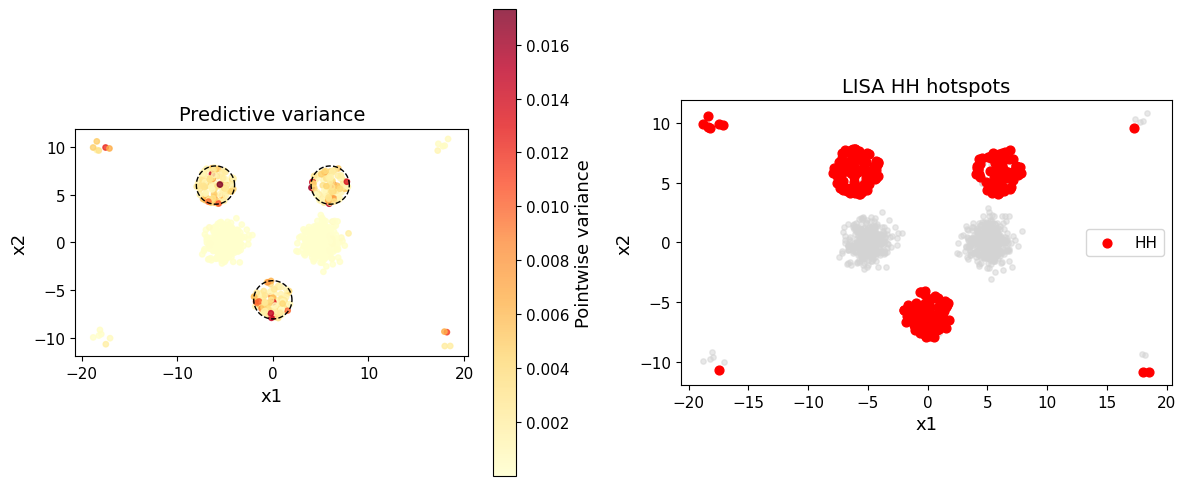

In [47]:
# Visualize variance and HH (three islands)
x1_test = X_test_raw["x1"].values
x2_test = X_test_raw["x2"].values
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc = axes[0].scatter(x1_test, x2_test, c=v, s=15, cmap="YlOrRd", alpha=0.8)
for c in gt.island_centers:
    theta = np.linspace(0, 2 * np.pi, 200)
    axes[0].plot(gt.island_radius * np.cos(theta) + c[0], gt.island_radius * np.sin(theta) + c[1], "k--", lw=1)
plt.colorbar(sc, ax=axes[0], label="Pointwise variance")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2"); axes[0].set_title("Predictive variance"); axes[0].set_aspect("equal")
axes[1].scatter(x1_test, x2_test, c="lightgray", s=15, alpha=0.5)
axes[1].scatter(x1_test[HH_mask], x2_test[HH_mask], c="red", s=40, label="HH", zorder=5)
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2"); axes[1].set_title("LISA HH hotspots"); axes[1].legend(); axes[1].set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / f"three_islands_pred_var_lisa.pdf", bbox_inches="tight")
plt.show()

Decision tree accuracy (HH vs non-HH): 0.9600


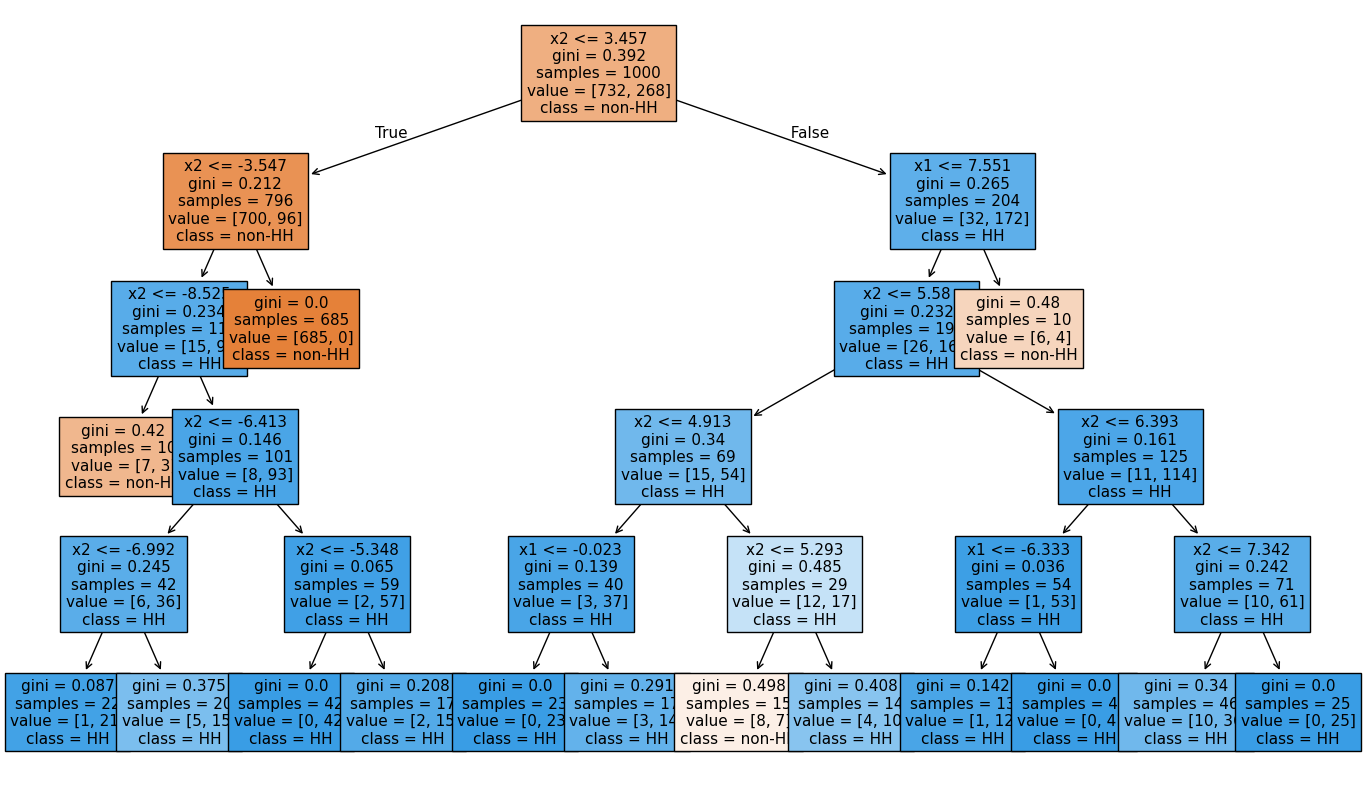

In [48]:
# Decision tree: HH vs non-HH (three islands)
X_test_2d = np.column_stack([x1_test, x2_test])
y_hh = HH_mask.astype(int)
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=SEED)
dt.fit(X_test_2d, y_hh)
print(f"Decision tree accuracy (HH vs non-HH): {dt.score(X_test_2d, y_hh):.4f}")
fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(dt, feature_names=["x1", "x2"], class_names=["non-HH", "HH"], filled=True, ax=ax, fontsize=11)
plt.tight_layout()
plt.show()

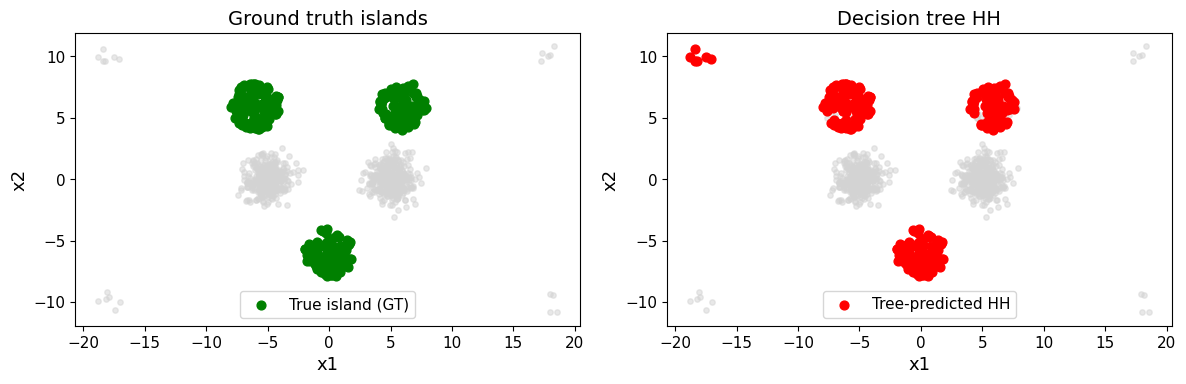

In [49]:
# Scatter: true HH (island) vs tree-predicted HH (three islands)
hh_pred = dt.predict(X_test_2d).astype(bool)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(x1_test, x2_test, c="lightgray", s=15, alpha=0.5)
axes[0].scatter(x1_test[island_test], x2_test[island_test], c="green", s=40, label="True island (GT)", zorder=5)
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2"); axes[0].set_title("Ground truth islands"); axes[0].legend(); axes[0].set_aspect("equal")
axes[1].scatter(x1_test, x2_test, c="lightgray", s=15, alpha=0.5)
axes[1].scatter(x1_test[hh_pred], x2_test[hh_pred], c="red", s=40, label="Tree-predicted HH", zorder=5)
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2"); axes[1].set_title("Decision tree HH"); axes[1].legend(); axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()

c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\weights.py:1294: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  out_w = W(neighbors, weights, id_order=self.id_order)


Observed Moran's I: 0.4215, null mean±std: -0.0001 ± 0.0077, p = 0.0099


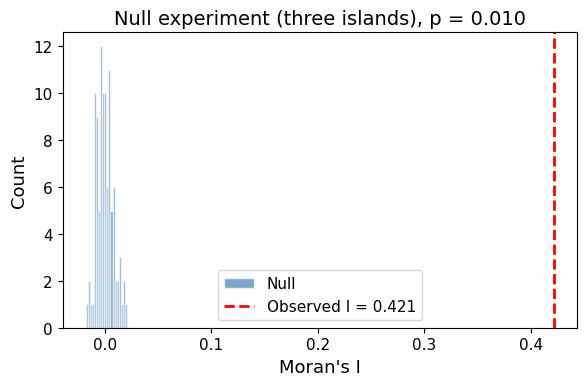

In [50]:
# Null experiment (three islands)
null_res = run_null(run_dir, X_test, K=K_actual, R=100, k=K_NN, seed=SEED)
observed_I = spatial["moran_i"]
null_moran = null_res["null_moran_i"]
p_emp = (1 + np.sum(null_moran >= observed_I)) / 101
print(f"Observed Moran's I: {observed_I:.4f}, null mean±std: {null_res['null_mean']:.4f} ± {null_res['null_std']:.4f}, p = {p_emp:.4f}")
plt.figure(figsize=(6, 4))
plt.hist(null_moran, bins=20, color="steelblue", alpha=0.7, edgecolor="white", label="Null")
plt.axvline(observed_I, color="red", linestyle="--", linewidth=2, label=f"Observed I = {observed_I:.3f}")
plt.xlabel("Moran's I"); plt.ylabel("Count"); plt.title(f"Null experiment (three islands), p = {p_emp:.3f}"); plt.legend()
plt.tight_layout()
plt.show()

### Thesis table: three-islands synthetic validation summary

Compact recovery and spatial metrics for the three-islands synthetic-validation subsection.


In [51]:
three_islands_tbl = pd.DataFrame([{
    "Design": "Three islands",
    "|HH|": int(HH_mask.sum()),
    "Precision": precision,
    "Recall": recall,
    "Jaccard": jaccard,
    "Moran's I": float(spatial["moran_i"]),
    "Empirical p-value": float(p_emp),
}])
display(three_islands_tbl)


,Design,|HH|,Precision,Recall,Jaccard,Moran's I,Empirical p-value
0,Three islands,268,0.962687,0.877551,0.848684,0.421453,0.009901


---
## Part C: Structural exception islands

Same pipeline on a third synthetic dataset: stable negative/positive blobs, a dense ordinary boundary strip at $p(y=1|x) \approx 0.5$, and two **structural exception disks** placed away from the ensemble decision boundary. Ground truth: `island_mask` (exception islands), `boundary_mask` (ordinary boundary strip, not the primary recovery target), `stable_mask`.


Samples: 11600, structural exceptions: 600, boundary: 5000, stable: 6000


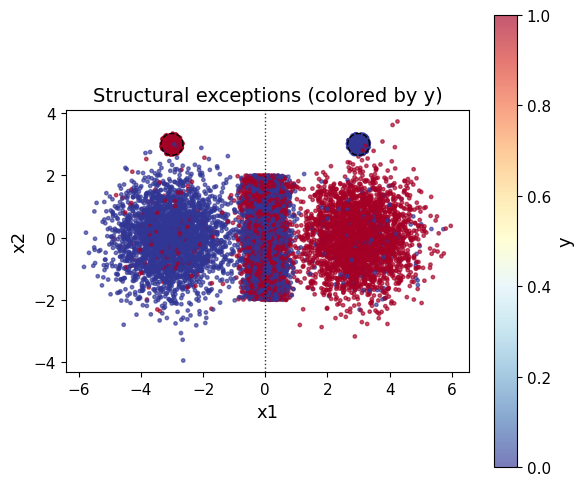

In [52]:
# Dataset 3: structural exception islands
X, y, feature_info, gt = make_synth_nonboundary_islands(
    random_state=SEED,
)

print(
    f"Samples: {len(X)}, structural exceptions: {gt.island_mask.sum()}, "
    f"boundary: {gt.boundary_mask.sum()}, stable: {gt.stable_mask.sum()}"
)

fig, ax = plt.subplots(figsize=(6, 5))

# Color all points by observed class label y, consistent with the other synthetic plots
sc = ax.scatter(
    X["x1"],
    X["x2"],
    c=y,
    s=6,
    alpha=0.65,
    cmap="RdYlBu_r",
    vmin=0,
    vmax=1,
)

# Mark the two expected structural exception regions
theta = np.linspace(0, 2 * np.pi, 200)
for c in gt.island_centers:
    ax.plot(
        gt.island_radius * np.cos(theta) + c[0],
        gt.island_radius * np.sin(theta) + c[1],
        "k--",
        lw=1,
    )

# Mark the ordinary boundary location
ax.axvline(0, color="black", linestyle=":", linewidth=1, alpha=0.8)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Structural exceptions (colored by y)")
ax.set_aspect("equal")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("y")

plt.tight_layout()
plt.savefig(FIG_DIR / "structural_exceptions_ground_truth.pdf", bbox_inches="tight")
plt.show()

In [53]:
# Train and save to a separate run dir
run_dir = RESULTS_DIR / "synthetic_structural_exceptions" / f"seed={SEED}"
run_dir.mkdir(parents=True, exist_ok=True)

preprocessor_factory = lambda fi: make_preprocessor(fi, scale_numeric=True)
split, meta, P_val, P_test, _ = run_one_training_run(
    X=X, y=y, feature_info=feature_info, preprocessor_factory=preprocessor_factory,
    outer_seed=SEED, n_candidates_per_family=50, test_size=0.2, val_size=0.2, verbose=1,
)
save_run_artifacts(
    run_dir,
    split,
    meta,
    P_val,
    P_test,
    config={"dataset": "synthetic_structural_exceptions", "seed": SEED},
)

preprocessor = preprocessor_factory(feature_info)
preprocessor.fit(X.iloc[split["train"]], y.iloc[split["train"]])
X_test_raw = X.iloc[split["test"]]
X_test = np.asarray(preprocessor.transform(X_test_raw))
print(f"Saved to {run_dir}, test size: {X_test.shape[0]}")


  [LogReg] 50 candidates trained
  [kNN] 50 candidates trained
  [RF] 50 candidates trained
  [GBM] 50 candidates trained
  [MLP] 50 candidates trained
Saved to C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\synthetic_structural_exceptions\seed=42, test size: 2320


In [54]:
# Rashomon + spatial
n_cand = len(load_meta(run_dir))
K_actual = min(K, n_cand)
P_rashomon = load_P_test(run_dir)[select_rashomon_global(run_dir, K=K_actual)]
spatial = run_spatial(run_dir, X_test, K=K_actual, k=K_NN)
mult = compute_multiplicity_metrics(P_rashomon, epsilon=0.05)
v = pointwise_variance(P_rashomon, ddof=0)
mean_pred = P_rashomon.mean(axis=0)
margin = np.abs(mean_pred - 0.5)
HH_mask = spatial["HH_mask"]
LL_mask = spatial["LL_mask"]
print(
    f"Moran's I: {spatial['moran_i']:.4f}, mean variance: {mult['mean_variance']:.6f}, "
    f"HH: {HH_mask.sum()}, LL: {LL_mask.sum()}"
)


Moran's I: 0.1999, mean variance: 0.000690, HH: 187, LL: 962


Variance vs decision-boundary margin (|mean prediction - 0.5|):
  Pearson r: 0.0182 (p=3.80e-01)
  Spearman r: 0.1111 (p=8.17e-08)
  Mean margin in HH: 0.3654
  Mean margin outside HH: 0.2438
  Mean margin in structural exceptions: 0.4241
  Mean margin in ordinary boundary: 0.0292
  Mean variance in structural exceptions: 0.002455
  Mean variance in ordinary boundary: 0.000601


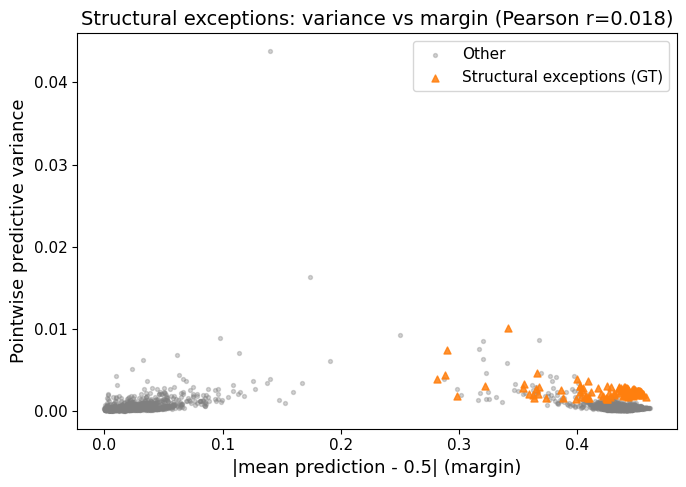

In [55]:
# Decision-boundary diagnostic: variance vs ensemble margin
test_idx = split["test"]
island_test = gt.island_mask[test_idx]
boundary_test = gt.boundary_mask[test_idx]

r_pearson, p_pearson = stats.pearsonr(v, margin)
r_spearman, p_spearman = stats.spearmanr(v, margin)

margin_hh_mean = margin[HH_mask].mean() if HH_mask.sum() else np.nan
margin_non_hh_mean = margin[~HH_mask].mean()
margin_island_mean = margin[island_test].mean() if island_test.sum() else np.nan
margin_boundary_mean = margin[boundary_test].mean() if boundary_test.sum() else np.nan
var_island_mean = v[island_test].mean() if island_test.sum() else np.nan
var_boundary_mean = v[boundary_test].mean() if boundary_test.sum() else np.nan

print("Variance vs decision-boundary margin (|mean prediction - 0.5|):")
print(f"  Pearson r: {r_pearson:.4f} (p={p_pearson:.2e})")
print(f"  Spearman r: {r_spearman:.4f} (p={p_spearman:.2e})")
print(f"  Mean margin in HH: {margin_hh_mean:.4f}")
print(f"  Mean margin outside HH: {margin_non_hh_mean:.4f}")
print(f"  Mean margin in structural exceptions: {margin_island_mean:.4f}")
print(f"  Mean margin in ordinary boundary: {margin_boundary_mean:.4f}")
print(f"  Mean variance in structural exceptions: {var_island_mean:.6f}")
print(f"  Mean variance in ordinary boundary: {var_boundary_mean:.6f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(margin[~island_test], v[~island_test], s=8, alpha=0.35, c="gray", label="Other")
ax.scatter(
    margin[island_test],
    v[island_test],
    s=25,
    alpha=0.85,
    c="C1",
    marker="^",
    label="Structural exceptions (GT)",
    zorder=5,
)
ax.set_xlabel("|mean prediction - 0.5| (margin)")
ax.set_ylabel("Pointwise predictive variance")
ax.set_title(f"Structural exceptions: variance vs margin (Pearson r={r_pearson:.3f})")
ax.legend(loc="best", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "structural_exceptions_variance_margin.pdf", bbox_inches="tight")
plt.show()

In [56]:
# Recovery: HH vs ground-truth structural exception islands
test_idx = split["test"]
island_test = gt.island_mask[test_idx]
boundary_test = gt.boundary_mask[test_idx]
tp = (HH_mask & island_test).sum()
pred_pos = HH_mask.sum()
true_pos = island_test.sum()
precision = tp / pred_pos if pred_pos else np.nan
recall = tp / true_pos if true_pos else np.nan
union = (HH_mask | island_test).sum()
jaccard = tp / union if union else np.nan
print("Recovery of ground-truth structural exceptions by LISA HH:")
print(f"  Precision: {precision:.4f}, Recall: {recall:.4f}, Jaccard: {jaccard:.4f}")
print(f"  TP={int(tp)}, |HH|={int(pred_pos)}, |island|={int(true_pos)}")
print(f"  HH on ordinary boundary (not GT target): {(HH_mask & boundary_test).sum()}")


Recovery of ground-truth structural exceptions by LISA HH:
  Precision: 0.6417, Recall: 1.0000, Jaccard: 0.6417
  TP=120, |HH|=187, |island|=120
  HH on ordinary boundary (not GT target): 28


FDR alpha sensitivity (structural exceptions):


,α,#HH,#components,max_component_size,Jaccard,Precision,Recall,DT Precision,DT Recall
0,0.01,120,2,60,0.904762,0.950000,0.95,0.967742,1.0
1,0.05,187,4,90,0.641711,0.641711,1.00,0.845070,1.0
2,0.10,282,3,230,0.425532,0.425532,1.00,0.528634,1.0
3,0.20,368,2,275,0.326087,0.326087,1.00,0.365854,1.0


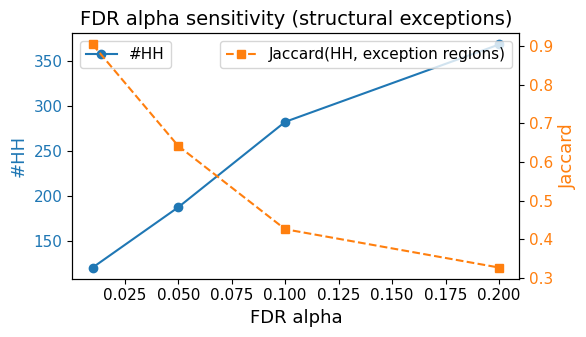

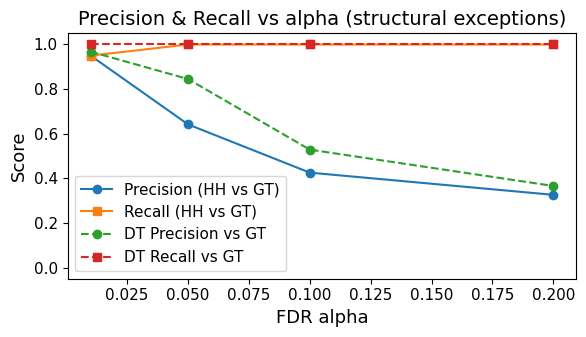

In [57]:
# FDR alpha sensitivity (Part C)
X_test_2d_c = np.column_stack([X_test_raw["x1"].values, X_test_raw["x2"].values])
fdr_alphas = [0.01, 0.05, 0.10, 0.20]

sens_df_c = load_or_compute_df(
    CACHE_DIR / f"nb08_structural_exceptions_fdr_{CACHE_VERSION}.parquet",
    lambda: compute_structural_exceptions_fdr_sensitivity(
        v,
        X_test,
        X_test_2d_c,
        island_test,
        fdr_alphas,
        k_nn=K_NN,
        seed=SEED,
    ),
    force=FORCE_RECOMPUTE,
)
print("FDR alpha sensitivity (structural exceptions):")
display(sens_df_c)

fig, ax1 = plt.subplots(figsize=(6, 3.5))
ax1.set_xlabel("FDR alpha")
ax1.plot(sens_df_c["α"], sens_df_c["#HH"], "o-", color="C0", label="#HH")
ax1.set_ylabel("#HH", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax2 = ax1.twinx()
ax2.plot(sens_df_c["α"], sens_df_c["Jaccard"], "s--", color="C1", label="Jaccard(HH, exception regions)")
ax2.set_ylabel("Jaccard", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
plt.title("FDR alpha sensitivity (structural exceptions)")
plt.tight_layout()
plt.savefig(FIG_DIR / "structural_exceptions_fdr_sensitivity.pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.set_xlabel("FDR alpha")
ax.plot(sens_df_c["α"], sens_df_c["Precision"], "o-", label="Precision (HH vs GT)")
ax.plot(sens_df_c["α"], sens_df_c["Recall"], "s-", label="Recall (HH vs GT)")
ax.plot(sens_df_c["α"], sens_df_c["DT Precision"], "o--", label="DT Precision vs GT")
ax.plot(sens_df_c["α"], sens_df_c["DT Recall"], "s--", label="DT Recall vs GT")
ax.set_ylabel("Score")
ax.legend(loc="best", fontsize=11)
ax.set_ylim(-0.05, 1.05)
plt.title("Precision & Recall vs alpha (structural exceptions)")
plt.tight_layout()
plt.savefig(FIG_DIR / "structural_exceptions_fdr_sensitivity_precision_recall.pdf", bbox_inches="tight")
plt.show()


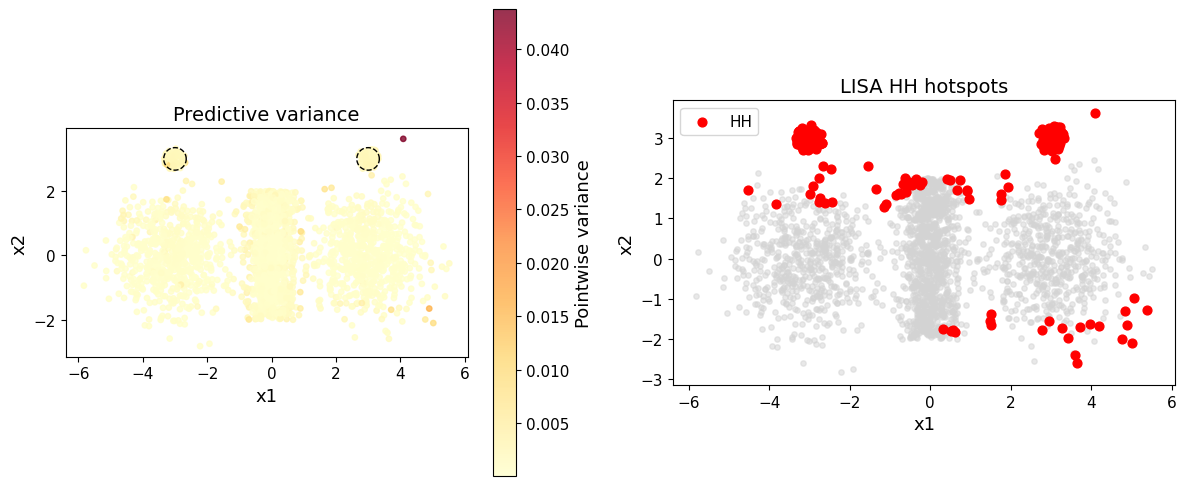

In [58]:
# Visualize variance and HH (structural exceptions)
x1_test = X_test_raw["x1"].values
x2_test = X_test_raw["x2"].values
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc = axes[0].scatter(x1_test, x2_test, c=v, s=15, cmap="YlOrRd", alpha=0.8)
for c in gt.island_centers:
    theta = np.linspace(0, 2 * np.pi, 200)
    axes[0].plot(
        gt.island_radius * np.cos(theta) + c[0],
        gt.island_radius * np.sin(theta) + c[1],
        "k--",
        lw=1,
    )
plt.colorbar(sc, ax=axes[0], label="Pointwise variance")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2"); axes[0].set_title("Predictive variance"); axes[0].set_aspect("equal")
axes[1].scatter(x1_test, x2_test, c="lightgray", s=15, alpha=0.5)
axes[1].scatter(x1_test[HH_mask], x2_test[HH_mask], c="red", s=40, label="HH", zorder=5)
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2"); axes[1].set_title("LISA HH hotspots"); axes[1].legend(); axes[1].set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / "structural_exceptions_pred_var_lisa.pdf", bbox_inches="tight")
plt.show()


Decision tree accuracy (HH vs non-HH): 0.9780


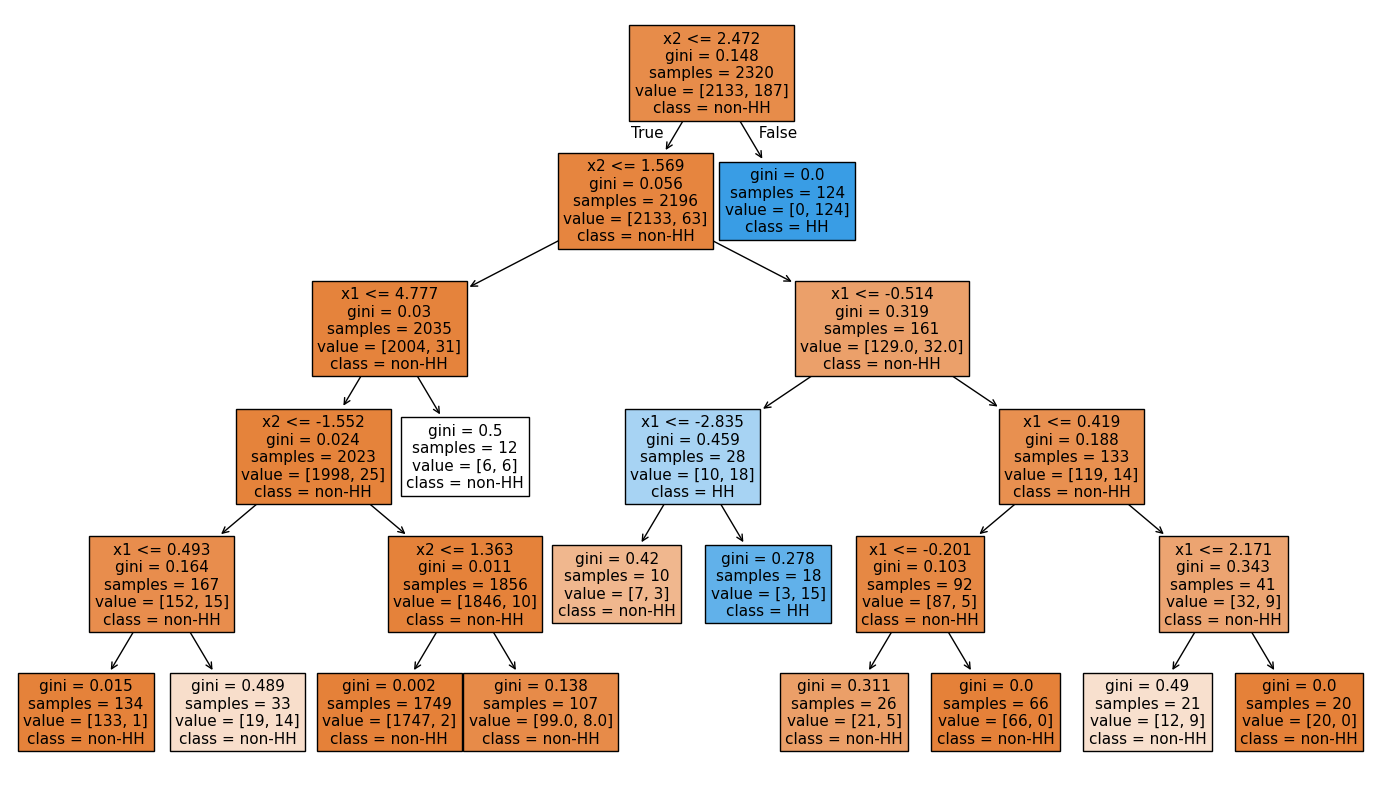

In [59]:
# Decision tree: HH vs non-HH (structural exceptions)
X_test_2d = np.column_stack([x1_test, x2_test])
y_hh = HH_mask.astype(int)
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=SEED)
dt.fit(X_test_2d, y_hh)
print(f"Decision tree accuracy (HH vs non-HH): {dt.score(X_test_2d, y_hh):.4f}")
fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(dt, feature_names=["x1", "x2"], class_names=["non-HH", "HH"], filled=True, ax=ax, fontsize=11)
plt.tight_layout()
plt.show()


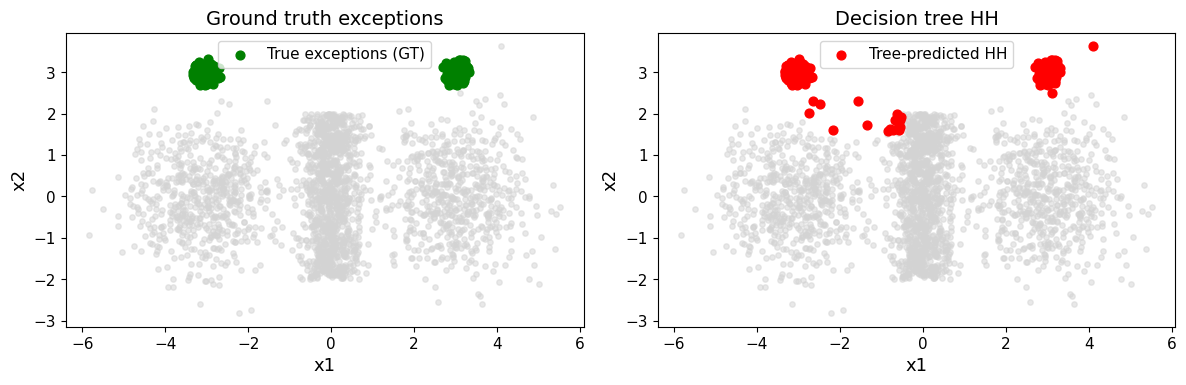

In [60]:
# Scatter: true structural exceptions vs tree-predicted HH
hh_pred = dt.predict(X_test_2d).astype(bool)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(x1_test, x2_test, c="lightgray", s=15, alpha=0.5)
axes[0].scatter(x1_test[island_test], x2_test[island_test], c="green", s=40, label="True exceptions (GT)", zorder=5)
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2"); axes[0].set_title("Ground truth exceptions"); axes[0].legend(); axes[0].set_aspect("equal")
axes[1].scatter(x1_test, x2_test, c="lightgray", s=15, alpha=0.5)
axes[1].scatter(x1_test[hh_pred], x2_test[hh_pred], c="red", s=40, label="Tree-predicted HH", zorder=5)
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2"); axes[1].set_title("Decision tree HH"); axes[1].legend(); axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()


Observed Moran's I: 0.1999, null mean±std: -0.0011 ± 0.0048, p = 0.0099


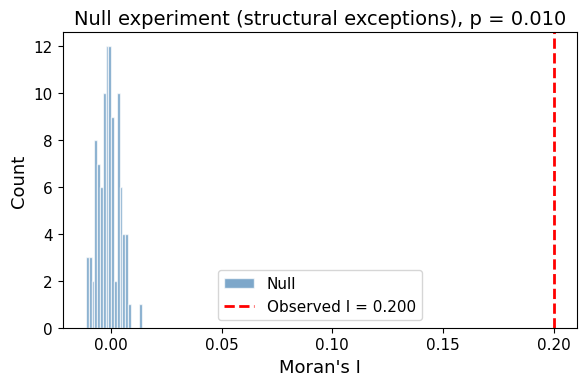

In [61]:
# Null experiment (structural exceptions)
null_res = run_null(run_dir, X_test, K=K_actual, R=100, k=K_NN, seed=SEED)
observed_I = spatial["moran_i"]
null_moran = null_res["null_moran_i"]
p_emp = (1 + np.sum(null_moran >= observed_I)) / 101
print(
    f"Observed Moran's I: {observed_I:.4f}, null mean±std: {null_res['null_mean']:.4f} ± {null_res['null_std']:.4f}, p = {p_emp:.4f}"
)
plt.figure(figsize=(6, 4))
plt.hist(null_moran, bins=20, color="steelblue", alpha=0.7, edgecolor="white", label="Null")
plt.axvline(observed_I, color="red", linestyle="--", linewidth=2, label=f"Observed I = {observed_I:.3f}")
plt.xlabel("Moran's I"); plt.ylabel("Count"); plt.title(f"Null experiment (structural exceptions), p = {p_emp:.3f}"); plt.legend()
plt.tight_layout()
plt.show()


### Thesis table: structural-exceptions synthetic validation summary

Compact recovery and spatial metrics for the structural-exception synthetic-validation subsection.


In [62]:
structural_exceptions_tbl = pd.DataFrame([{
    "Design": "Structural exceptions",
    "|HH|": int(HH_mask.sum()),
    "Precision": precision,
    "Recall": recall,
    "Jaccard": jaccard,
    "Moran's I": float(spatial["moran_i"]),
    "Empirical p-value": float(p_emp),
    "Pearson r (var vs margin)": float(r_pearson),
    "Spearman r (var vs margin)": float(r_spearman),
    "Mean margin HH": margin_hh_mean,
    "Mean margin non-HH": margin_non_hh_mean,
    "Mean margin structural exceptions": margin_island_mean,
    "Mean margin ordinary boundary": margin_boundary_mean,
    "Mean variance structural exceptions": var_island_mean,
    "Mean variance ordinary boundary": var_boundary_mean,
}])
display(structural_exceptions_tbl)
structural_exceptions_tbl.to_csv(TABLE_DIR / "structural_exceptions_summary.csv", index=False)


,Design,|HH|,Precision,Recall,Jaccard,Moran's I,Empirical p-value,Pearson r (var vs margin),Spearman r (var vs margin),Mean margin HH,Mean margin non-HH,Mean margin structural exceptions,Mean margin ordinary boundary,Mean variance structural exceptions,Mean variance ordinary boundary
0,Structural exceptions,187,0.641711,1.0,0.641711,0.199921,0.009901,0.018237,0.111067,0.365448,0.243836,0.424119,0.029189,0.002455,0.000601
